In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os

# Check what's inside your Google Drive
print(os.listdir('/content/drive/MyDrive'))

['Call for members- Literature Community .gform', 'Untitled form (File responses)', 'Untitled form.gform', 'Earthquake_project', 'Colab Notebooks']


In [ ]:
print(os.listdir('/content/drive/MyDrive/Earthquake_project'))

['Damage', 'undamaged']


In [ ]:
print("Damage/images:", os.listdir('/content/drive/MyDrive/Earthquake_project/Damage/Images')[:5])
print("Damage/annotations:", os.listdir('/content/drive/MyDrive/Earthquake_project/Damage/Annotation')[:5])
print("Undamaged (first 5):", os.listdir('/content/drive/MyDrive/Earthquake_project/undamaged')[:5])

Damage/images: ['016c9211b879b1b0c50feb4223b16a78.jpg', '013d799520719d03479603ca2e6c830b.jpg', '013a2c385a5bbec843f823ebf82a5dcc.jpg', '0010db654b64dfa30d3a3941228bace8.jpg', '013f681015595f4b349aa9917c911ec5.jpg']
Damage/annotations: []
Undamaged (first 5): ['00a85d9e93b2325b4466847ac52c6461.jpg', '001ebfcdb6ca3fb659e5b108ff8ae272.jpg', '001d29d2f6f791833c2cb20425830afa.jpg', '00d2a1a2a323ac9ae1b891e0d61de674.jpg', '00d4d85d60bdec9545f8e33d47e561d9.jpg']


In [ ]:
damage_imgs   = len(os.listdir('/content/drive/MyDrive/Earthquake_project/Damage/Images'))
damage_ann    = len(os.listdir('/content/drive/MyDrive/Earthquake_project/Damage/Annotation'))
nodamage_imgs = len(os.listdir('/content/drive/MyDrive/Earthquake_project/undamaged'))

print(f"Damage images     : {damage_imgs}")
print(f"Damage annotations: {damage_ann}")
print(f"Undamaged images  : {nodamage_imgs}")

Damage images     : 804
Damage annotations: 0
Undamaged images  : 300


In [ ]:
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
import os
import shutil

# FIXED PATHS
DAMAGE_DIR   = '/content/drive/MyDrive/Earthquake_project/Damage/Images'
NODAMAGE_DIR = '/content/drive/MyDrive/Earthquake_project/undamaged'

# Create output folders
os.makedirs('/content/dataset/Damaged',   exist_ok=True)
os.makedirs('/content/dataset/No_Damage', exist_ok=True)

# Copy Damage images
for img in os.listdir(DAMAGE_DIR):
    if img.lower().endswith(('.jpg', '.jpeg', '.png')):
        shutil.copy(f'{DAMAGE_DIR}/{img}', f'/content/dataset/Damaged/{img}')

# Copy Undamaged images
for img in os.listdir(NODAMAGE_DIR):
    if img.lower().endswith(('.jpg', '.jpeg', '.png')):
        shutil.copy(f'{NODAMAGE_DIR}/{img}', f'/content/dataset/No_Damage/{img}')

print("Damaged images :", len(os.listdir('/content/dataset/Damaged')))
print("No_Damage images:", len(os.listdir('/content/dataset/No_Damage')))

Damaged images : 804
No_Damage images: 300


In [ ]:
import random

CLASSES = ['Damaged', 'No_Damage']
SPLITS  = {'train': 0.70, 'val': 0.15, 'test': 0.15}

# Create split folders
for cls in CLASSES:
    for split in SPLITS:
        os.makedirs(f'/content/split/{split}/{cls}', exist_ok=True)

# Split images
for cls in CLASSES:
    images = os.listdir(f'/content/dataset/{cls}')
    images = [f for f in images if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(images)

    total     = len(images)
    train_end = int(total * 0.70)
    val_end   = int(total * 0.85)

    sets = {
        'train': images[:train_end],
        'val':   images[train_end:val_end],
        'test':  images[val_end:]
    }

    for split, imgs in sets.items():
        for img in imgs:
            shutil.copy(
                f'/content/dataset/{cls}/{img}',
                f'/content/split/{split}/{cls}/{img}'
            )

    print(f'{cls}: {train_end} train | {total-train_end-int(total*0.15)} val | {int(total*0.15)} test')

Damaged: 562 train | 122 val | 120 test
No_Damage: 210 train | 45 val | 45 test


In [ ]:
from PIL import Image
import os

def preprocess_check(split_dir):
    corrupted = 0
    total = 0
    for cls in ['Damaged', 'No_Damage']:
        folder = f'{split_dir}/{cls}'
        for img_file in os.listdir(folder):
            if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                total += 1
                try:
                    img = Image.open(f'{folder}/{img_file}')
                    img.verify()  # check if image is corrupted
                except Exception as e:
                    print(f'Corrupted: {img_file} — removing')
                    os.remove(f'{folder}/{img_file}')
                    corrupted += 1
    print(f'Checked {total} images | Removed {corrupted} corrupted')

print("Checking train...")
preprocess_check('/content/split/train')
print("Checking val...")
preprocess_check('/content/split/val')
print("Checking test...")
preprocess_check('/content/split/test')

Checking train...
Checked 772 images | Removed 0 corrupted
Checking val...
Checked 166 images | Removed 0 corrupted
Checking test...
Checked 166 images | Removed 0 corrupted


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    '/content/split/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build model
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x      = GlobalAveragePooling2D()(base.output)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)

# Handle class imbalance (804 vs 300)
class_weight = {0: 1.0, 1: 2.5}

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight
)

# Save model to Drive
model.save('/content/drive/MyDrive/Earthquake_project/earthquake_model.h5')
print("✅ Model saved to Google Drive!")

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    '/content/split/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build model
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x      = GlobalAveragePooling2D()(base.output)
x      = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)

# Handle class imbalance (804 vs 300)
class_weight = {0: 1.0, 1: 2.5}

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weight
)

# Save model to Drive
model.save('/content/drive/MyDrive/Earthquake_project/earthquake_model.h5')
print("✅ Model saved to Google Drive!")

Found 772 images belonging to 2 classes.
Found 166 images belonging to 2 classes.
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 182s 7s/step - accuracy: 0.4728 - loss: 1.1459 - val_accuracy: 0.5843 - val_loss: 0.6929
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 167s 7s/step - accuracy: 0.6231 - loss: 0.9770 - val_accuracy: 0.7108 - val_loss: 0.5835
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 175s 7s/step - accuracy: 0.6697 - loss: 0.8901 - val_accuracy: 0.7831 - val_loss: 0.4996
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 177s 7s/step - accuracy: 0.6749 - loss: 0.8714 - val_accuracy: 0.7771 - val_loss: 0.4969
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 157s 6s/step - accuracy: 0.7034 - loss: 0.8350 - val_accuracy: 0.7289 - val_loss: 0.5284
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 162s 6s/step - accuracy: 0.6969 - loss: 0.8455 - val_accuracy: 0.7530 - val_loss: 0.5008
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.6969 - loss: 0.7914 - val_accuracy: 0.8072 - val_loss: 0.4488
Epoch 8/15
25/25 ━━━━━━━━━━━━

✅ Model saved to Google Drive!


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Data generators
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)
val_data = val_gen.flow_from_directory(
    '/content/split/val',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

# Build MobileNetV2
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

x = GlobalAveragePooling2D()(base.output)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base.input, outputs=output)
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Class weights to handle imbalance
class_weight = {0: 1.0, 1: 2.68}  # 804/300 ratio

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    class_weight=class_weight,
    callbacks=[early_stop, reduce_lr]
)

# Save
model.save('/content/drive/MyDrive/Earthquake_project/earthquake_model.h5')
print("✅ Model saved!")
print(f"Best val_accuracy: {max(history.history['val_accuracy']):.2%}")

Found 772 images belonging to 2 classes.
Found 166 images belonging to 2 classes.
Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 206s 8s/step - accuracy: 0.6256 - loss: 1.2821 - val_accuracy: 0.7590 - val_loss: 0.5522 - learning_rate: 0.0010
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.7008 - loss: 1.0157 - val_accuracy: 0.7651 - val_loss: 0.6274 - learning_rate: 0.0010
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 156s 6s/step - accuracy: 0.7306 - loss: 0.9009 - val_accuracy: 0.7831 - val_loss: 0.4829 - learning_rate: 0.0010
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 152s 6s/step - accuracy: 0.7552 - loss: 0.7714 - val_accuracy: 0.8072 - val_loss: 0.4401 - learning_rate: 0.0010
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 172s 7s/step - accuracy: 0.7746 - loss: 0.7073 - val_accuracy: 0.7952 - val_loss: 0.4335 - learning_rate: 0.0010
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 158s 6s/step - accuracy: 0.7876 - loss: 0.7161 - val_accuracy: 0.7831 - val_loss: 0.4534 - learning_rate: 0.0010
Epoch 7/20
2

✅ Model saved!
Best val_accuracy: 80.72%


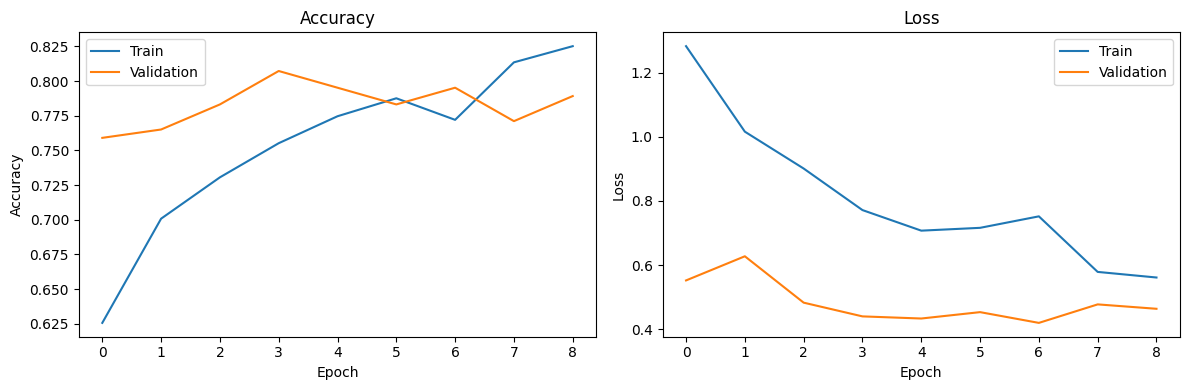

✅ Graph saved to Drive!


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Earthquake_project/accuracy_graph.png')
plt.show()
print("✅ Graph saved to Drive!")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


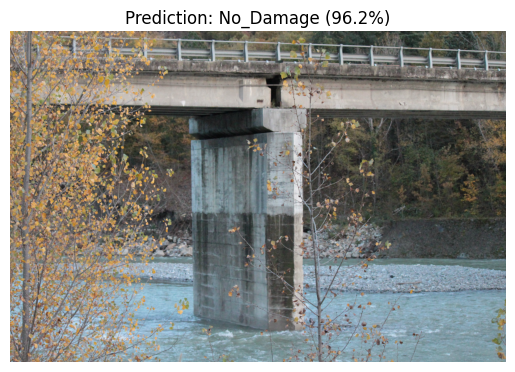

Prediction : No_Damage
Confidence : 96.2%


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Pick first test image
test_folder = '/content/split/test/Damaged'
test_img = os.listdir(test_folder)[0]

img = image.load_img(f'{test_folder}/{test_img}', target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]
label = 'Damaged' if pred > 0.5 else 'No_Damage'
confidence = pred if pred > 0.5 else 1 - pred

plt.imshow(image.load_img(f'{test_folder}/{test_img}'))
plt.title(f'Prediction: {label} ({confidence*100:.1f}%)')
plt.axis('off')
plt.show()

print(f"Prediction : {label}")
print(f"Confidence : {confidence*100:.1f}%")

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import random
import os

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array, verbose=0)[0][0]
    label = 'Damaged' if pred > 0.5 else 'No_Damage'
    confidence = pred if pred > 0.5 else 1 - pred
    return label, confidence * 100

# Pick 6 random images from test folder (mix of both classes)
test_images = []
for cls in ['Damaged', 'No_Damage']:
    folder = f'/content/split/test/{cls}'
    imgs = os.listdir(folder)
    random.shuffle(imgs)
    for img in imgs[:3]:  # 3 from each class
        test_images.append((f'{folder}/{img}', cls))

# Plot results
plt.figure(figsize=(15, 10))
for i, (img_path, true_label) in enumerate(test_images):
    label, confidence = predict_image(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(image.load_img(img_path))

    # Green title if correct, red if wrong
    color = 'green' if label == true_label else 'red'
    plt.title(f'Pred: {label}\nConf: {confidence:.1f}%\nTrue: {true_label}',
              color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Model Predictions on Test Images', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Earthquake_project/test_predictions.png')
plt.show()
print("✅ Saved to Drive!")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/Earthquake_project/earthquake_model.h5'
)

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,203 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

 Optimizer params: 2 (12.00 B)

In [ ]:
for i, layer in enumerate(model.layers):
    print(i, layer.name)

0 input_layer_2
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_rel

In [ ]:
from tensorflow.keras.models import Model

feature_extractor = Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

print("✅ Feature Extractor Created")

✅ Feature Extractor Created


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

feature_gen = ImageDataGenerator(rescale=1./255)

damaged_data = feature_gen.flow_from_directory(
    '/content/split/test',
    classes=['Damaged'],
    target_size=(224,224),
    batch_size=32,
    class_mode=None,
    shuffle=False
)

features = feature_extractor.predict(damaged_data)

print(features.shape)

Found 121 images belonging to 1 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step
(121, 128)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

print("✅ Features Standardized")
print(features_scaled.shape)

✅ Features Standardized
(121, 128)


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=3.0,
    min_samples=5
)

clusters = dbscan.fit_predict(features_scaled)

print("Cluster Labels:")
print(clusters)

Cluster Labels:
[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1]


In [ ]:
import numpy as np

unique_clusters = np.unique(clusters)

print("Unique Clusters:", unique_clusters)

for cluster in unique_clusters:
    count = np.sum(clusters == cluster)
    print(f"Cluster {cluster}: {count} images")

Unique Clusters: [-1]
Cluster -1: 121 images


In [ ]:
print(features_scaled.shape)

(121, 128)


In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

for eps in [5, 8, 10, 12, 15, 20]:
    db = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = db.fit_predict(features_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(
        f"eps={eps} | clusters={n_clusters} | noise={n_noise}"
    )

eps=5 | clusters=0 | noise=121
eps=8 | clusters=0 | noise=121
eps=10 | clusters=2 | noise=111
eps=12 | clusters=1 | noise=54
eps=15 | clusters=1 | noise=6
eps=20 | clusters=1 | noise=0


In [ ]:
import pandas as pd

cluster_counts = pd.Series(clusters).value_counts().sort_index()

print(cluster_counts)

0    33
1    57
2    31
Name: count, dtype: int64


In [ ]:
results = pd.DataFrame({
    'Image': damaged_data.filenames,
    'Cluster': clusters
})

results.head()

,Image,Cluster
0,Damaged/0010db654b64dfa30d3a3941228bace8.jpg,1
1,Damaged/00b21b8b3fe6bf11f8ec5a221ef10887.jpg,2
2,Damaged/02b9152d2f4f526ed31893cd026e1b4e.jpg,1
3,Damaged/03e9b908baf291fa7502cdc14bcb6344.jpg,0
4,Damaged/04bc1893efafe963f4c1be755edd9a72.jpg,1


In [ ]:
import pandas as pd

print(results['Cluster'].value_counts())

Cluster
1    57
0    33
2    31
Name: count, dtype: int64


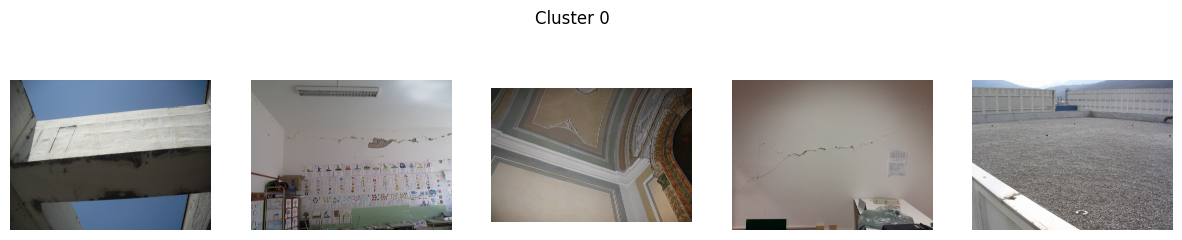

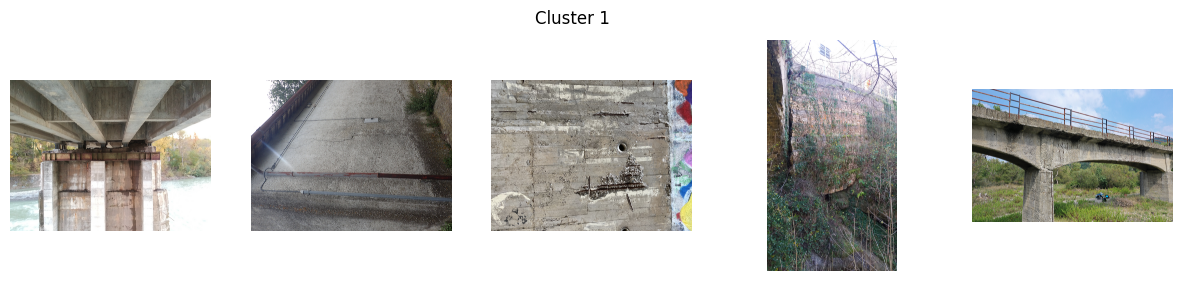

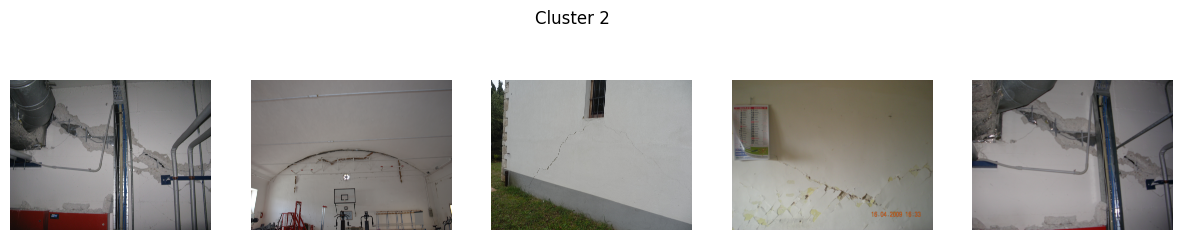

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import random

for cluster_id in sorted(results['Cluster'].unique()):

    cluster_imgs = results[
        results['Cluster'] == cluster_id
    ]['Image'].tolist()

    sample_imgs = random.sample(
        cluster_imgs,
        min(5, len(cluster_imgs))
    )

    plt.figure(figsize=(15,3))

    for i, img_name in enumerate(sample_imgs):

        img_path = f"/content/split/test/{img_name}"

        plt.subplot(1,5,i+1)
        plt.imshow(image.load_img(img_path))
        plt.axis('off')

    plt.suptitle(f'Cluster {cluster_id}')
    plt.show()

In [ ]:
cluster_mapping = {
    0: 'Low Damage',
    1: 'Moderate Damage',
    2: 'High Damage',
    3: 'Severe Damage'
}

In [ ]:
results['Damage_Level'] = results['Cluster'].map(cluster_mapping)

results.head()

,Image,Cluster,Damage_Level
0,Damaged/0010db654b64dfa30d3a3941228bace8.jpg,1,Moderate Damage
1,Damaged/00b21b8b3fe6bf11f8ec5a221ef10887.jpg,2,High Damage
2,Damaged/02b9152d2f4f526ed31893cd026e1b4e.jpg,1,Moderate Damage
3,Damaged/03e9b908baf291fa7502cdc14bcb6344.jpg,0,Low Damage
4,Damaged/04bc1893efafe963f4c1be755edd9a72.jpg,1,Moderate Damage


In [ ]:
results.to_csv(
    '/content/drive/MyDrive/Earthquake_project/final_damage_levels.csv',
    index=False
)

print("✅ Final damage levels saved")

✅ Final damage levels saved


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_damage_level(img_path):

    # Load image
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Stage 1: Damage Detection
    pred = model.predict(img_array, verbose=0)[0][0]

    if pred <= 0.5:
        return "No Damage"

    # Stage 2: Feature Extraction
    feature = feature_extractor.predict(img_array, verbose=0)

    feature_scaled = scaler.transform(feature)

    cluster = kmeans.predict(feature_scaled)[0]

    return cluster_mapping[cluster]

In [ ]:
import os

folder = "/content/split/test/Damaged"

print(os.listdir(folder)[:10])

['04bc1893efafe963f4c1be755edd9a72.jpg', '9b742d9a15edea37a823ac21ac6987a0.jpg', '5e936ef3e9ec2ddde2893821fe3f48e1.jpg', '8f87ae0c67f5c08d180b8f4a0a85b85d.jpg', '8d37130536f19b81b7d2961a392c1aba.jpg', '5cdce2d945ac96804ae99ffae6d24e54.jpg', '4af7f978fc7a0ea67cb740ab686c869b.jpg', '5cd9270960c10db0d9486f7c34a5b4d2.jpg', '8fe822c2af0c94bc35535113dc8bb261.jpg', '3e9c6bc5df1f1d90e382c998875d224e.jpg']


In [ ]:
result = predict_damage_level(
    "/content/split/test/Damaged/9b742d9a15edea37a823ac21ac6987a0.jpg"
)

print("Damage Level:", result)

Damage Level: No Damage


In [ ]:
img = image.load_img(
    "/content/split/test/Damaged/0010db654b64dfa30d3a3941228bace8.jpg",
    target_size=(224,224)
)

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array, verbose=0)[0][0]

print("Prediction Score:", pred)

Prediction Score: 0.047843046


In [ ]:
print(train_data.class_indices)

NameError: name 'train_data' is not defined

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

print(train_data.class_indices)

Found 772 images belonging to 2 classes.
{'Damaged': 0, 'No_Damage': 1}


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_damage_level(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0][0]

    print("Raw Prediction:", pred)

    # Damaged = 0
    # No_Damage = 1

    if pred > 0.5:
        return "No Damage"

    feature = feature_extractor.predict(img_array, verbose=0)

    feature_scaled = scaler.transform(feature)

    cluster = kmeans.predict(feature_scaled)[0]

    return cluster_mapping[cluster]

In [ ]:
result = predict_damage_level(
    "/content/split/test/Damaged/21dc54adc171dbd7c7b25568c0d153de.jpg"
)

print("Final Result:", result)

FileNotFoundError: [Errno 2] No such file or directory: '/content/split/test/Damaged/21dc54adc171dbd7c7b25568c0d153de.jpg'

In [ ]:
print(cluster_mapping)

{0: 'Low Damage', 1: 'Moderate Damage', 2: 'High Damage', 3: 'Severe Damage'}


In [ ]:
import os

print(os.path.exists(
    "/content/split/test/Damaged/21dc54adc171dbd7c7b25568c0d153de.jpg"
))

False


In [ ]:
import os

files = os.listdir("/content/split/test/Damaged")

print("Number of files:", len(files))
print(files[:20])

Number of files: 121
['04bc1893efafe963f4c1be755edd9a72.jpg', '9b742d9a15edea37a823ac21ac6987a0.jpg', '5e936ef3e9ec2ddde2893821fe3f48e1.jpg', '8f87ae0c67f5c08d180b8f4a0a85b85d.jpg', '8d37130536f19b81b7d2961a392c1aba.jpg', '5cdce2d945ac96804ae99ffae6d24e54.jpg', '4af7f978fc7a0ea67cb740ab686c869b.jpg', '5cd9270960c10db0d9486f7c34a5b4d2.jpg', '8fe822c2af0c94bc35535113dc8bb261.jpg', '3e9c6bc5df1f1d90e382c998875d224e.jpg', '2c449ef8010a00e65e8f71f371f6bb7f.jpg', '1d62a5a25f571316847de620be9b20b2.jpg', '9ad0de62556fb02f6ede47da1b96b847.jpg', '7a62aefb52649cf727ae282f31fd1d49.jpg', '6c8965d320bf157d329927bef03da1ee.jpg', '5cbe16c1c7a053053ee7a7a9fcd39ae2.jpg', '0ae10d2f1406654cecfa34547019c3f4.jpg', '4c8f0cd6d4d54b8fca469422f5e133bc.jpg', '7b8b94776f862184a28592237f2e6421.jpg', '8c355b10c75c9f72ab96c2fab9e6a520.jpg']


In [ ]:
target = "21dc54adc171dbd7c7b25568c0d153de"

for f in os.listdir("/content/split/test/Damaged"):
    if target in f:
        print(f)

In [ ]:
import os

folder = "/content/split/test/Damaged"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print(img_path)

result = predict_damage_level(img_path)

print(result)

/content/split/test/Damaged/04bc1893efafe963f4c1be755edd9a72.jpg
Raw Prediction: 0.037932545
Moderate Damage


In [ ]:
print(os.listdir("/content/split/test"))

['Damaged', 'No_Damage']


In [ ]:
import os

folder = "/content/split/test/Damaged"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Testing:", img_name)

result = predict_damage_level(img_path)

print("Final Result:", result)

Testing: 04bc1893efafe963f4c1be755edd9a72.jpg
Raw Prediction: 0.037932545
Final Result: Moderate Damage


In [ ]:
folder = "/content/split/test/No_Damage"

img_name = os.listdir(folder)[0]
img_path = os.path.join(folder, img_name)

print("Testing:", img_name)

result = predict_damage_level(img_path)

print("Final Result:", result)

Testing: 0e0dcb1502b097226ac4b2c2054ada6e.jpg
Raw Prediction: 0.86232233
Final Result: No Damage
